In [2]:
dvc = 'cpu'
from dolfinx import fem, mesh as msh
from dolfinx.io import XDMFFile
from mpi4py import MPI
from FEniCSx_solver import plot_fn
import torch
import ufl
import numpy as np
from FEniCSx_solver import interpolate_expr, SUPG_grad_adjoint_method_solver
from FEniCSx_PyTorch_interface import fem_solver


G = torch.load(f='data/revised_set/input_values/raw/G_0.pt', weights_only=False).to(device=dvc)

with XDMFFile(MPI.COMM_WORLD, f"data/revised_set/mesh_files/mesh_{0}.xdmf", "r") as xdmf:
    mesh = xdmf.read_mesh(name="mesh")
Wh = fem.functionspace(mesh=mesh, element=('CG', 1))
Whd = fem.functionspace(mesh=mesh, element=('DG', 0))
ufun = fem.Function(Wh)
ufun_d = fem.Function(Whd)
u = ufl.TrialFunction(Wh)
v = ufl.TestFunction(Wh)

mesh.topology.create_connectivity(1, 2)
boundary_facets = msh.exterior_facet_indices(mesh.topology)
boundary_dofs = fem.locate_dofs_topological(Wh, 1, boundary_facets)

x = ufl.SpatialCoordinate(mesh)
b = ufl.as_vector((fem.Constant(mesh, np.cos(-np.pi/3.0)), fem.Constant(mesh, np.sin(-np.pi/3.0))))
f = fem.Constant(mesh, 0.0)
eps = fem.Constant(mesh, 1e-8)

u = ufl.TrialFunction(Wh)
v = ufl.TestFunction(Wh)


expr = ufl.conditional(
    ufl.ge(x[1], 0.7 + ufl.sin(-ufl.pi/3)/ufl.cos(-ufl.pi/3)*x[0]),
    1,
    0
) * ufl.conditional(
    ufl.Or(ufl.eq(x[1], 0), ufl.eq(x[0],1)),
    0,
    1
)
uD = interpolate_expr(expr=expr, Wh=Wh)
bcs = [fem.dirichletbc(uD, boundary_dofs)]
pde_data = mesh,Wh,ufun,eps,b,None,f,None,bcs

u_target = fem.Function(Wh)
u_target.x.array[:] = torch.clone(G.u_bjk).cpu().detach().numpy()
loss_form = (ufun-u_target)**2 * ufl.dx
fs = fem_solver(SUPG_grad_adjoint_method_solver(pde_data=pde_data, loss_form=loss_form))


import torch
from torch.utils.data import TensorDataset, DataLoader
from torch import nn
from IPython.display import clear_output
import numpy as np
import matplotlib.pyplot as plt
import torch_geometric as tg

dvc = 'cpu'
G = torch.load(f='data/revised_set/input_values/raw/G_0.pt', weights_only=False).to(device=dvc)
idofs = torch.clone(G.interior_dofs)


X = torch.clone(G.midpoints[:,0]).cpu().detach().numpy().flatten()
Y = torch.clone(G.midpoints[:,1]).cpu().detach().numpy().flatten()

Z0 = torch.clone(G.y_optimized_z).cpu().detach().numpy().flatten()
Z1 = torch.clone(G.y_optimized_z).cpu().detach().numpy().flatten()

z0 = torch.clone(G.y_optimized_z)
z1 = torch.clone(G.y_optimized_z)


target = torch.clone(G.y_optimized_z)[idofs]


class GAT_NN0(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.gat1 = tg.nn.models.GAT(
            in_channels=9,
            hidden_channels=256,
            num_layers=4,
            out_channels=256, 
            v2 = True,
            add_self_loops=False
        ).to(device=dvc)

        self.mlp_main = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        ).to(device=dvc)
        self.mlp_aux = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        ).to(device=dvc)

    def forward(self, data) -> torch.Tensor:
        x, edge_index  = data.x0, data.edge_index
        z = self.gat1(
            x=x,
            edge_index=edge_index
        )
        z_main = self.mlp_main(z)
        z_aux = self.mlp_aux(z)
        return z_main[idofs], z_aux[idofs]
    
class NN(torch.nn.Module):
    def __init__(self, n:int):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(n, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 64),
            nn.Sigmoid(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 64),
            nn.Sigmoid(),
            nn.Linear(64, 256),
            nn.ReLU(),
        ).to(device=dvc)
        self.mlp_main = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        ).to(device=dvc)
        self.mlp_aux = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        ).to(device=dvc)
    def forward(self, data) -> torch.Tensor:
        z1 = self.mlp(data)
        z_main = self.mlp_main(z1)
        z_aux = self.mlp_aux(z1)
        return z_main, z_aux
    
    
model0 = GAT_NN0()
model1 = NN(9)



huber = torch.nn.HuberLoss(reduction='sum')
l2 = torch.nn.MSELoss(reduction='sum')
def loss_fn(pred, target):
    return 0.7*huber(pred[0], target) + 0.3*l2(pred[1], target)

optimizer0 = torch.optim.Adam(model0.parameters(), lr=1e-3, weight_decay=1e-5)
optimizer1 = torch.optim.Adam(model1.parameters(), lr=1e-3, weight_decay=1e-5)

checkpoint0 = torch.load("data/models/gat_revised0.pth", map_location=dvc)
model0.load_state_dict(checkpoint0["model_state"])
optimizer0.load_state_dict(checkpoint0["optimizer_state"])

checkpoint1 = torch.load("data/models/revised0.pth", map_location=dvc)
model1.load_state_dict(checkpoint1["model_state"])
optimizer1.load_state_dict(checkpoint1["optimizer_state"])



lossarr0 = np.load('data/loss_arrays/sup_loss_x0.npy')

act_lossarr0 = np.load('data/loss_arrays/act_sup_loss_x0.npy')



lossarr1 = np.load('data/loss_arrays/gat_sup_loss_x0.npy')

act_lossarr1 = np.load('data/loss_arrays/gat_act_sup_loss_x0.npy')


losses0 = list(lossarr0)

losses_act0 = list(act_lossarr0)

z0[idofs] = model0(G)[0]
z1[idofs] = model1(G.x0)[0][idofs]

act_loss0 = fs(z0)
act_loss1 = fs(z1)
fs(z0)
print(act_loss0, act_loss1)
plot_fn(fs.fs.uh)

tensor(2.6600e-06, grad_fn=<FEniCSx_PyTorch_interfaceBackward>) tensor(9.6433e-06, grad_fn=<FEniCSx_PyTorch_interfaceBackward>)


Widget(value='<iframe src="http://localhost:49578/index.html?ui=P_0x33d86b620_0&reconnect=auto" class="pyvista…

# upper limit of local approach

In [3]:
inflow_dofs = torch.clone(G.inflow_dofs).detach().cpu().numpy()
outflow_dofs = torch.clone(G.outflow_dofs).detach().cpu().numpy()
inner_dofs = torch.clone(G.interior_dofs).detach().cpu().numpy()

x = torch.clone(G.x0).detach().cpu().numpy()
values, counts = np.unique(x, return_counts=True, axis=0)

mask = counts > 1
indices = [np.flatnonzero((x == row).all(axis=1)) for row in values[mask]]

target = torch.clone(G.y_optimized_z).detach().cpu().numpy()
y_test2 = target.copy()

for i in range(len(indices)):
    y_test2[indices[i]] = np.mean(target[indices[i]])
print(np.linalg.norm(target-y_test2))
y_test3 = y_test2.copy()
y_test3[outflow_dofs] = target[outflow_dofs]
y_test3[inflow_dofs] = target[inflow_dofs]
print(np.linalg.norm(target-y_test3))

0.023497181
0.023398025


In [4]:
fs(G.y_optimized_l)

tensor(3.0780e-06)

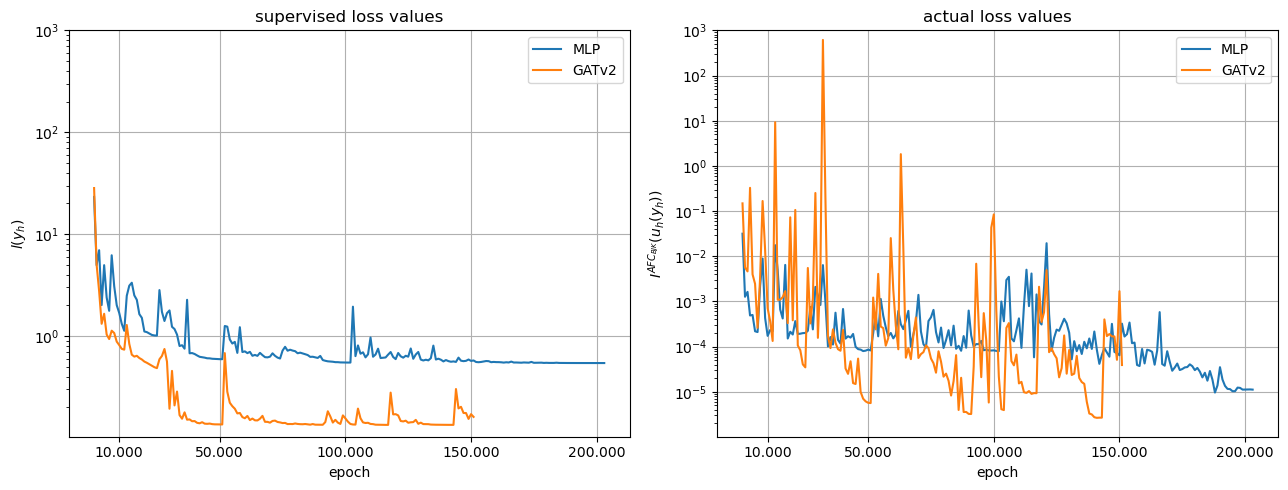

In [92]:
from matplotlib.ticker import FuncFormatter



x_vals = 1000*np.arange(len(lossarr0))
x_vals1 = 1000*np.arange(len(lossarr1))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax11, ax12 = axes.flatten()

ax11.plot(x_vals, lossarr0,  label='MLP')
ax12.plot(x_vals, act_lossarr0,  label='MLP', linestyle='-', color='C0')

ax11.set_ylabel('$l (y_h)$')

ax11.set_yscale('log')
#ax11.set_xscale('log')
ax11.tick_params(axis='y')
ax11.set_xticks([10000, 50000, 100000, 150000, 200000])
ax11.plot(x_vals1, lossarr1,  label='GATv2')
ax12.plot(x_vals1, act_lossarr1,  label='GATv2', linestyle='-', color='C1')
ax12.set_ylabel('$I^{AFC_{BJK}} (u_h (y_h))$')

ax11.set_xlabel('epoch')
ax12.set_xlabel('epoch')

ax12.set_yscale('log')
#ax12.set_xscale('log')
ax12.set_xticks([10000, 50000, 100000, 150000, 200000])
ax11.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", "."))
)
ax12.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", "."))
)
ax12.tick_params(axis='y')
ax11.grid()
ax12.grid()
ax11.legend()
ax11.set_title('supervised loss values')
ax12.legend()
ax11.set_ylim(0, 1e+3)
ax12.set_title('actual loss values')
ax12.set_ylim(0, 1e+3)

plt.tight_layout()
plt.show()

In [6]:
lossarr0[act_lossarr0 == np.min(act_lossarr0)]

array([0.54456538])

In [7]:
lossarr1[act_lossarr1 == np.min(act_lossarr1)]

array([0.13459666])

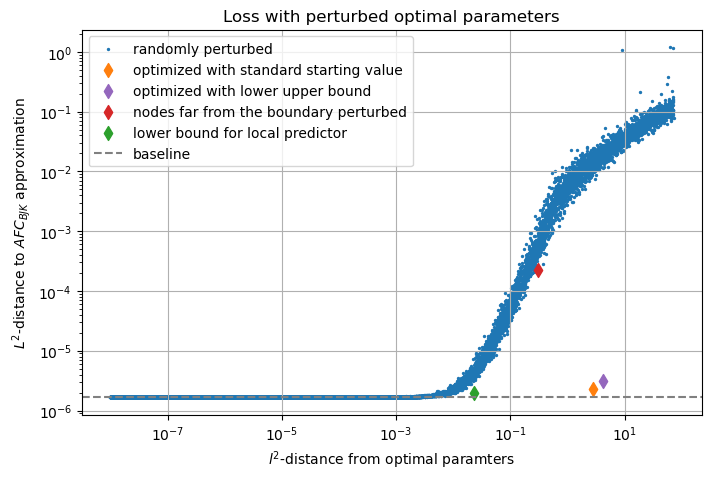

In [95]:
pert_mag = np.load('data/loss_arrays/pert_mag.npy')
losses = np.load('data/loss_arrays/pert_losses.npy')

u_opt = torch.clone(G.u_optimized).detach().numpy().flatten()
u_opt_l = torch.clone(G.u_optimized_l).detach().numpy().flatten()
u_opt_z = torch.clone(G.u_optimized_z).detach().numpy().flatten()
y_opt = torch.clone(G.y_optimized).detach().numpy().flatten()
y_opt_b = torch.clone(G.y_optimized_b).detach().numpy().flatten()
y_opt_z = torch.clone(G.y_optimized_z).detach().numpy().flatten()
y_opt_l = torch.clone(G.y_optimized_l).detach().numpy().flatten()
y_test = y_opt_z.copy()
midpoints = torch.clone(G.midpoints).detach().cpu().numpy()

y_test[np.logical_not(np.isclose(midpoints[:,1], 0.7 - 1.732*midpoints[:,0], rtol=1e-2, atol=0.5))] += 1e-2
y_test[np.isclose(midpoints[:,0],1-1e-3, atol=1e-1)] = y_opt_z[np.isclose(midpoints[:,0],1-1e-3, atol=1e-1)]
y_test[np.isclose(midpoints[:,1],1-1e-3, atol=1e-1)] = y_opt_z[np.isclose(midpoints[:,1],1-1e-3, atol=1e-1)]

plt.figure(figsize=(8, 5))
plt.scatter(pert_mag, losses, s=2, alpha=1, label='randomly perturbed', color='C0')
fs.fs.set_weights(y_opt)
plt.scatter(x=np.linalg.norm(y_opt-y_opt_z), y=fs.fs.loss(), s=50, color=f"C1", label="optimized with standard starting value", marker='d')
fs.fs.set_weights(y_opt_l)
plt.scatter(x=np.linalg.norm(y_opt_l-y_opt_z), y=fs.fs.loss(), s=50, color=f"C4", label="optimized with lower upper bound", marker='d')
fs.fs.set_weights(y_test)
plt.scatter(x=np.linalg.norm(y_test-y_opt_z), y=fs.fs.loss(), s=50, color=f"C3", label="nodes far from the boundary perturbed", marker='d')
fs.fs.set_weights(y_test2.flatten())
plt.scatter(x=np.linalg.norm(y_test2.flatten()-y_opt_z), y=fs.fs.loss(), s=50, color=f"C2", label="lower bound for local predictor", marker='d')



fs.fs.set_weights(y_opt_z)
plt.axhline(fs.fs.loss(), linestyle='--', color='gray', label='baseline')
plt.legend()
plt.gca()
plt.grid()
plt.title('Loss with perturbed optimal parameters')
plt.xlabel('$l^2$-distance from optimal paramters')
plt.ylabel('$L^2$-distance to $AFC_{BJK}$ approximation')
plt.yscale('log')
plt.xscale('log')
plt.show()

In [74]:
fs(z0)
print(np.linalg.norm(fs.fs.yh.x.array-y_opt_z), fs.fs.loss())
fs(z1)
print(np.linalg.norm(fs.fs.yh.x.array-y_opt_z), fs.fs.loss())
fs.fs.set_weights(y_test)
print(np.linalg.norm(fs.fs.yh.x.array-y_opt_z), fs.fs.loss())

0.4550890092692287 2.6599821685691287e-06
0.9152703262058349 9.643286160646956e-06
0.3001666136629501 0.00022274186500631784


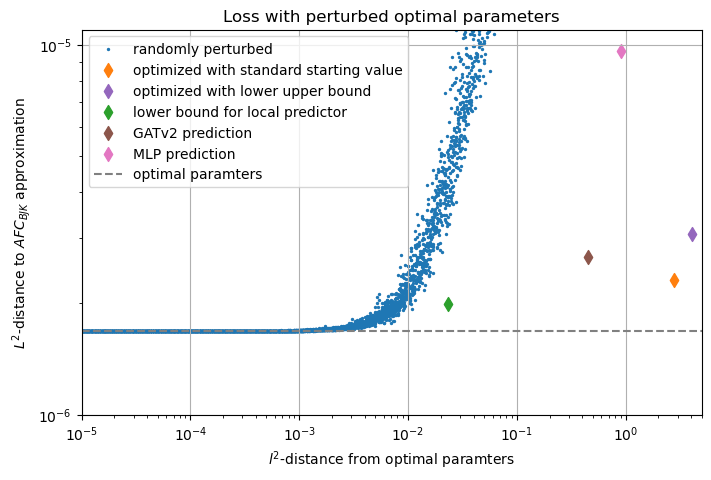

In [94]:
pert_mag = np.load('data/loss_arrays/pert_mag.npy')
losses = np.load('data/loss_arrays/pert_losses.npy')

u_opt = torch.clone(G.u_optimized).detach().numpy().flatten()
u_opt_l = torch.clone(G.u_optimized_l).detach().numpy().flatten()
u_opt_z = torch.clone(G.u_optimized_z).detach().numpy().flatten()
y_opt = torch.clone(G.y_optimized).detach().numpy().flatten()
y_opt_b = torch.clone(G.y_optimized_b).detach().numpy().flatten()
y_opt_z = torch.clone(G.y_optimized_z).detach().numpy().flatten()
y_opt_l = torch.clone(G.y_optimized_l).detach().numpy().flatten()
y_test = y_opt_z.copy()
midpoints = torch.clone(G.midpoints).detach().cpu().numpy()


y_test[np.logical_not(np.isclose(midpoints[:,1], 0.7 - 1.732*midpoints[:,0], rtol=1e-2, atol=0.5))] += 1e-2
y_test[np.isclose(midpoints[:,0],1-1e-3, atol=1e-1)] = y_opt_z[np.isclose(midpoints[:,0],1-1e-3, atol=1e-1)]
y_test[np.isclose(midpoints[:,1],1+1e-3, atol=1e-1)] = y_opt_z[np.isclose(midpoints[:,1],1+1e-3, atol=1e-1)]

plt.figure(figsize=(8, 5))
plt.scatter(pert_mag, losses, s=2, alpha=1, label='randomly perturbed', color='C0')

fs.fs.set_weights(y_opt)
plt.scatter(x=np.linalg.norm(y_opt-y_opt_z), y=fs.fs.loss(), s=50, color=f"C1", label="optimized with standard starting value", marker='d')
fs.fs.set_weights(y_opt_l)
plt.scatter(x=np.linalg.norm(y_opt_l-y_opt_z), y=fs.fs.loss(), s=50, color=f"C4", label="optimized with lower upper bound", marker='d')
fs.fs.set_weights(y_test2.flatten())
plt.scatter(x=np.linalg.norm(y_test2.flatten()-y_opt_z), y=fs.fs.loss(), s=50, color=f"C2", label="lower bound for local predictor", marker='d')
fs(z0)
plt.scatter(x=np.linalg.norm(fs.fs.yh.x.array-y_opt_z), y=fs.fs.loss(), s=50, color=f"C5", label="GATv2 prediction", marker='d')
fs(z1)
plt.scatter(x=np.linalg.norm(fs.fs.yh.x.array-y_opt_z), y=fs.fs.loss(), s=50, color=f"C6", label="MLP prediction", marker='d')

fs.fs.set_weights(y_opt_z)
plt.axhline(fs.fs.loss(), linestyle='--', color='gray', label='optimal paramters')
plt.legend()
plt.gca()
plt.title('Loss with perturbed optimal parameters')
plt.xlabel('$l^2$-distance from optimal paramters')
plt.ylabel('$L^2$-distance to $AFC_{BJK}$ approximation')
plt.yscale('log')
plt.xscale('log')
plt.ylim(1e-6, 1.1*1e-5)
plt.xlim(1e-5, 5)
#plt.yticks(np.append(1e-6*np.arange(1,10),1e-5))
plt.grid()
plt.show()

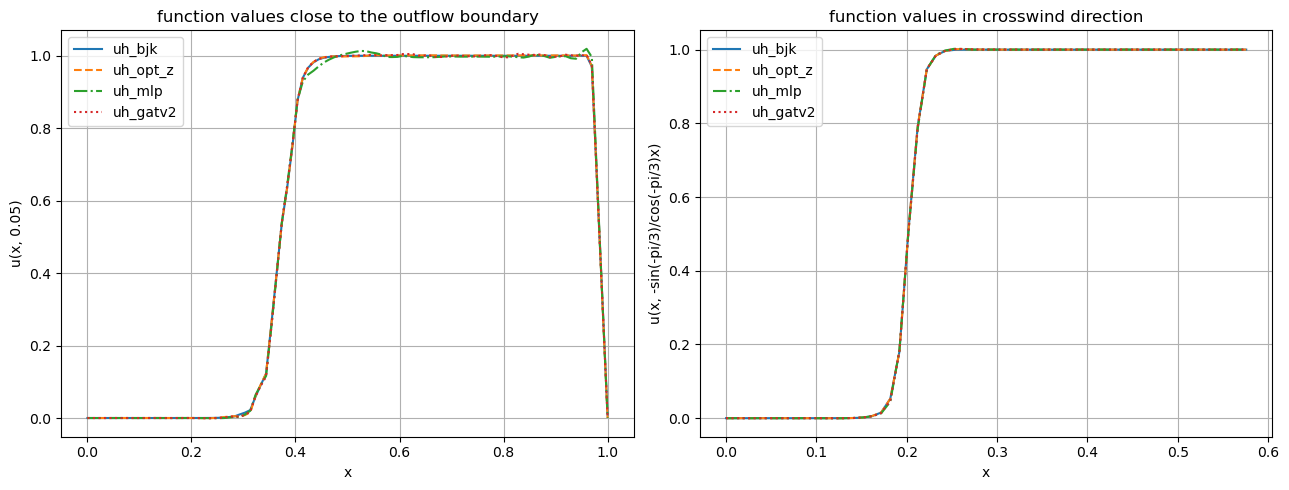

In [250]:
u_opt = torch.clone(G.u_optimized).detach().numpy().flatten()
u_opt_l = torch.clone(G.u_optimized_l).detach().numpy().flatten()
u_opt_z = torch.clone(G.u_optimized_z).detach().numpy().flatten()
u_bjk = torch.clone(G.u_bjk).detach().numpy().flatten()
u_std = torch.clone(G.u_std).detach().cpu().numpy()
y_opt = torch.clone(G.y_optimized).detach().numpy().flatten()
y_opt_b = torch.clone(G.y_optimized_b).detach().numpy().flatten()
y_opt_z = torch.clone(G.y_optimized_z).detach().numpy().flatten()
y_opt_l = torch.clone(G.y_optimized_l).detach().numpy().flatten()

mesh = fs.fs.domain
mesh.anem = 'mesh'
V = fs.fs.uh.function_space
Y = fs.fs.Yh
B = fem.functionspace(mesh=mesh, element=("P", 1, (2,)))
b = fem.Function(B)

b1=interpolate_expr(fs.fs.b[0], V)
b2=interpolate_expr(fs.fs.b[1], V)
b.sub(0).interpolate(b1)
b.sub(1).interpolate(b2)
b.name = 'b'

eps, c, f, g = interpolate_expr(fs.fs.eps,V), interpolate_expr(fs.fs.c,V), interpolate_expr(fs.fs.f,V), interpolate_expr(fs.fs.g,V)
uD = fs.fs.bcs[0].g
uD.name = 'uD'
eps.name = 'eps'
f.name = 'f'
g.name = 'g'
uh_opt, uh_opt_z, uh_opt_l, uh_std, uh_bjk, uh_gatv2, uh_mlp = fem.Function(fs.fs.Wh), fem.Function(fs.fs.Wh), fem.Function(fs.fs.Wh), fem.Function(fs.fs.Wh), fem.Function(fs.fs.Wh), fem.Function(fs.fs.Wh), fem.Function(fs.fs.Wh)
uh_opt.x.array[:] = u_opt
uh_opt.name = 'uh_opt'
uh_opt_z.x.array[:] = u_opt_z
uh_opt_z.name = 'uh_opt_z'
uh_opt_l.x.array[:] = u_opt_l
uh_opt_l.name = 'uh_opt_l'
uh_std.x.array[:] = u_std
uh_std.name = 'uh_std'
uh_bjk.x.array[:] = u_bjk
uh_bjk.name = 'uh_bjk'

fs(z0)
uh_gatv2.x.array[:] = fs.fs.uh.x.array.copy()
uh_gatv2.name = 'uh_gatv2'
fs(z1)
uh_mlp.x.array[:] = fs.fs.uh.x.array.copy()
uh_mlp.name = 'uh_mlp'

from FEniCSx_solver import curve_plotter
t = np.linspace(0, 1, 100)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax11, ax12 = axes.flatten()

points = np.vstack((t, 5*1e-2*np.ones_like(t), np.zeros_like(t))).T

values = curve_plotter(u=uh_bjk, points=points)
ax11.plot(t, values, linestyle='-', color=f'C0', label='uh_bjk')

values = curve_plotter(u=uh_opt_z, points=points)
ax11.plot(t, values, linestyle='--', color=f'C1', label='uh_opt_z')

values = curve_plotter(u=uh_mlp, points=points)
ax11.plot(t, values, linestyle='-.', color=f'C2', label='uh_mlp')

values = curve_plotter(u=uh_gatv2, points=points)
ax11.plot(t, values, linestyle=':', color=f'C3', label='uh_gatv2')
ax11.set_xlabel("x")

ax11.set_ylabel("u(x, 0.05)")
ax11.legend()
ax11.set_title('function values close to the outflow boundary')
ax11.grid()

points = np.vstack((t, -np.sin(-np.pi/3)/np.cos(-np.pi/3)*t, np.zeros_like(t))).T
values = curve_plotter(u=uh_bjk, points=points)
ax12.plot(t, values, linestyle='-', color=f'C0', label='uh_bjk')

values = curve_plotter(u=uh_opt_z, points=points)
ax12.plot(t, values, linestyle='--', color=f'C1', label='uh_opt_z')

values = curve_plotter(u=uh_mlp, points=points)
ax12.plot(t, values, linestyle='-.', color=f'C2', label='uh_mlp')

values = curve_plotter(u=uh_gatv2, points=points)
ax12.plot(t, values, linestyle=':', color=f'C3', label='uh_gatv2')
ax12.set_xlabel("x")
ax12.set_ylabel("u(x, -sin(-pi/3)/cos(-pi/3)x)")
ax12.legend()
ax12.set_title('function values in crosswind direction')
ax12.grid()
plt.tight_layout()
plt.show()

In [73]:
from dolfinx import io


u_opt = torch.clone(G.u_optimized).detach().numpy().flatten()
u_opt_l = torch.clone(G.u_optimized_l).detach().numpy().flatten()
u_opt_z = torch.clone(G.u_optimized_z).detach().numpy().flatten()
u_bjk = torch.clone(G.u_bjk).detach().numpy().flatten()
u_std = torch.clone(G.u_std).detach().cpu().numpy()
y_opt = torch.clone(G.y_optimized).detach().numpy().flatten()
y_opt_b = torch.clone(G.y_optimized_b).detach().numpy().flatten()
y_opt_z = torch.clone(G.y_optimized_z).detach().numpy().flatten()
y_opt_l = torch.clone(G.y_optimized_l).detach().numpy().flatten()

mesh = fs.fs.domain
mesh.anem = 'mesh'
V = fs.fs.uh.function_space
Y = fs.fs.Yh
B = fem.functionspace(mesh=mesh, element=("P", 1, (2,)))
b = fem.Function(B)

b1=interpolate_expr(fs.fs.b[0], V)
b2=interpolate_expr(fs.fs.b[1], V)
b.sub(0).interpolate(b1)
b.sub(1).interpolate(b2)
b.name = 'b'

eps, c, f, g = interpolate_expr(fs.fs.eps,V), interpolate_expr(fs.fs.c,V), interpolate_expr(fs.fs.f,V), interpolate_expr(fs.fs.g,V)
uD = fs.fs.bcs[0].g
uD.name = 'uD'
eps.name = 'eps'
f.name = 'f'
g.name = 'g'
uh_opt, uh_opt_z, uh_opt_l, uh_std, uh_bjk, uh_gatv2, uh_mlp = fem.Function(fs.fs.Wh), fem.Function(fs.fs.Wh), fem.Function(fs.fs.Wh), fem.Function(fs.fs.Wh), fem.Function(fs.fs.Wh), fem.Function(fs.fs.Wh), fem.Function(fs.fs.Wh)
uh_opt.x.array[:] = u_opt
uh_opt.name = 'uh_opt'
uh_opt_z.x.array[:] = u_opt_z
uh_opt_z.name = 'uh_opt_z'
uh_opt_l.x.array[:] = u_opt_l
uh_opt_l.name = 'uh_opt_l'
uh_std.x.array[:] = u_std
uh_std.name = 'uh_std'
uh_bjk.x.array[:] = u_bjk
uh_bjk.name = 'uh_bjk'

fs(z0)
uh_gatv2.x.array[:] = fs.fs.uh.x.array.copy()
uh_gatv2.name = 'uh_gatv2'
fs(z1)
uh_mlp.x.array[:] = fs.fs.uh.x.array.copy()
uh_mlp.name = 'uh_mlp'

funs = [uh_opt, uh_opt_z, uh_opt_l, uh_std, uh_bjk, uh_gatv2, uh_mlp]


yh_opt, yh_opt_z, yh_opt_l, yh_test, yh_pert = fem.Function(fs.fs.Yh), fem.Function(fs.fs.Yh), fem.Function(fs.fs.Yh), fem.Function(fs.fs.Yh), fem.Function(fs.fs.Yh)
yh_opt.x.array[:] = y_opt
yh_opt.name = 'yh_opt'
yh_opt_z.x.array[:] = y_opt_z
yh_opt_z.name = 'yh_opt_z'
yh_opt_l.x.array[:] = y_opt_l
yh_opt_l.name = 'yh_opt_l'

y_test = y_opt_z.copy()
midpoints = torch.clone(G.midpoints).detach().cpu().numpy()


y_test[np.logical_not(np.isclose(midpoints[:,1], 0.7 - 1.732*midpoints[:,0], rtol=1e-2, atol=0.5))] += 1e-2
y_test[np.isclose(midpoints[:,0],1-1e-3, atol=1e-1)] = y_opt_z[np.isclose(midpoints[:,0],1-1e-3, atol=1e-1)]
y_test[np.isclose(midpoints[:,1],1+1e-3, atol=1e-1)] = y_opt_z[np.isclose(midpoints[:,1],1+1e-3, atol=1e-1)]

yh_test.x.array[:] = y_test
yh_test.name = 'yh_test'

y_pert = np.zeros_like(yh_pert.x.array)

y_pert[np.logical_not(np.isclose(midpoints[:,1], 0.7 - 1.732*midpoints[:,0], rtol=1e-2, atol=0.5))] = 1
y_pert[np.isclose(midpoints[:,0],1-1e-3, atol=1e-1)] = 0
y_pert[np.isclose(midpoints[:,1],0+1e-3, atol=1e-1)] = 0
yh_pert.x.array[:] = y_pert
yh_pert.name = 'yh_pert'

params = [yh_opt, yh_opt_z, yh_opt_l, yh_test, yh_pert]

with io.XDMFFile(MPI.COMM_WORLD, f"data/models/results/revised_results.xdmf", "w") as xdmf:
    xdmf.write_mesh(mesh)
    xdmf.write_function(u=eps)
    xdmf.write_function(u=b)
    xdmf.write_function(u=g)
    xdmf.write_function(u=f)
    xdmf.write_function(u=uD)
    for fun in funs:
        xdmf.write_function(u=fun)
    for param in params:
        xdmf.write_function(u=param)